### Evasion dataset 

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import yaml
from pathlib import Path


In [3]:
# configs 
my_font = dict(
            family="Courier New, monospace",
            size=18,
            color="Black",
            variant="small-caps",
) 

## Loading datasets

In [4]:
"""
Loading the datasets

"""
def get_config_file(): 
    try:
        base_dir = Path(__file__).resolve().parent.parent
        path = base_dir / "configs" / "training.yaml"
        return path
    except NameError: # if it is a jupyter file 
        return Path("/training-app/configs/training.yaml")


def load_config(CONFIG_PATH) :
  """
  Selects the current dataset's config file we are interest in.
  """
  try:
      with open(CONFIG_PATH, "r") as f:
        full_config = yaml.safe_load(f)
  except Exception as e:
    print(f"Config file not found {e}")
    raise


  try:
    current_dataset = full_config["CURRENT_DATASET"]
    print(f"\nloading current dataset: {current_dataset}")
    if current_dataset not in full_config['DATASETS']:
      raise ValueError(f"\nDataset {current_dataset} not found!")

    return full_config["DATASETS"][current_dataset]

  except Exception as e:
    print(f"There was an error handling the config cleaning.yaml file {e}")
    raise


CONFIG_PATH = get_config_file()
dfs = load_config(CONFIG_PATH)


loading current dataset: CIENCIA_DA_COMPUTACAO


### Selecting desired dataset -> df_train


In [5]:
"""
Selecting desired dataset -> df_train
"""
df_train = pd.read_csv(dfs['TRAINING_DATASET'])
df_active = pd.read_csv(dfs['ACTIVE_DATASET'])
df_deactive = pd.read_csv(dfs['EVADED_DATASET'])
df_history = pd.read_csv(dfs['HISTORY_DATASET'])

## Checking the general info of the dataset

We need to extract the following features:
    - For each semester, we need to calculate the CR - Coeficiente de Rendimento
    - The total Amount of failings per semester 
    - The total Diciplines made per semester (Credits)
    - CR_Trend - Change in CR from last semester (Coeficiente)
    - Failure_rate - % of subjects failed so far
    - % of subjects failed so far
    - Delayed_Progress	Are they behind schedule?


- We must create the Lag_Academico
  - Tempo_de_Permanenca - Idade_Academica 
    - Lag 0   -> The student is on track
    - Lag > 2 -> The student is behind
    - Lag < 0 -> The student is an overachiever 

- We can also create the Velocidade_Progresso
  - ( Idade_Academica / Tempo_de_Permanencia )  
  - 1.0 -> velocidade ok
  - 0.5 -> Student taking 2x to finish the classes

## Handling History dataset - this later on will be a dag in airflow

In [6]:
df_history_v0 = df_history.copy()
df_history_v0 = df_history_v0.sort_values(by='RGA_Anon')
df_history_v0.drop(columns={"Faltas", "Codigo_Turma", "Equivalencia", "Codigo_Disciplina", "Curso_Ofertante", "Observacao", "Ano"}, inplace=True)

In [7]:
"""
Here, we'll consider failure to a subject as 1 and non-failure as 0
    - MA will be disconsidered

"""
df_history_v0 = df_history_v0[df_history_v0['Situação'] != "MA"]
failures = ['RMF', 'RM', 'RP', 'RF']

df_history_v0['Situação']  = np.where(
    df_history_v0['Situação'].isin(failures),
    1,
    0
)

In [8]:
"""
Here we calculate the weighted faiulure - Reprovacao_Ponderada_Semestral - How many credits did the student fail
"""
def calculate_weighted_failured( df: pd.DataFrame) -> pd.DataFrame:
    
    df['Reprovacao_Ponderada_Semestral'] = df["Crédito"].to_numpy() * df["Situação"].to_numpy()

    df['Reprovacao_Ponderada_Semestral'] = (
        df.groupby(["AnoSem",  "RGA_Anon"])["Reprovacao_Ponderada_Semestral"]
        .transform("sum")
    )

    return df
df_history_v2 = calculate_weighted_failured(df_history_v0)

In [9]:
"""
Here we calculate - [Reprovação_Media_Semestral] - how much percent of the total credits taken does the student fail

    - 0.0 -> student did not fail a single one subject
    - 1.0 -> student failed all subjects
"""
def calculate_failure_ratio (df: pd.DataFrame) -> pd.DataFrame:
    total_credit = df.groupby(["AnoSem",  "RGA_Anon"])['Crédito'].transform("sum").to_numpy() 
    total_credit = total_credit.astype("float")

    df['Reprovacao_Ponderada_Semestral'] = df['Reprovacao_Ponderada_Semestral'].astype("float")
    
    df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)

    return df
df_history_v3 = calculate_failure_ratio(df_history_v2)

/tmp/ipykernel_24/1197268355.py:13: RuntimeWarning: invalid value encountered in divide
  df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)


In [10]:
df_history_v3['AnoSem'] = ( 
    np.where(df_history_v3['AnoSem'] % 1 == .5,
    df_history_v3['AnoSem'] -.3,
    df_history_v3['AnoSem'] +.1
    ) 
    )

In [11]:
"""
Here, we will need the - Período ingresso - feature to calculate the permanence time
"""

all_students = pd.concat([df_active, df_deactive], axis=0)
df_history_v4 = df_history_v3.merge(all_students[['RGA_Anon', 'Período ingresso']], on='RGA_Anon', how='left')

In [12]:
periodo_ingresso = sorted(df_history_v4['Período ingresso'].unique())

print("As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006")
display(periodo_ingresso)

all_ano = sorted(df_history_v4['AnoSem'].unique())
display(all_ano)

print("We must therefore drop all the history that happened before 2009")


As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006


[np.int64(20091),
 np.int64(20101),
 np.int64(20111),
 np.int64(20121),
 np.int64(20131),
 np.int64(20141),
 np.int64(20151),
 np.int64(20161),
 np.int64(20162),
 np.int64(20171),
 np.int64(20172),
 np.int64(20181),
 np.int64(20191),
 np.int64(20201),
 np.int64(20211),
 np.int64(20221),
 np.int64(20222),
 np.int64(20231),
 np.int64(20232),
 np.int64(20241),
 np.int64(20242),
 np.int64(20251)]

[np.float64(2006.2),
 np.float64(2007.1),
 np.float64(2008.1),
 np.float64(2009.1),
 np.float64(2009.2),
 np.float64(2010.1),
 np.float64(2010.2),
 np.float64(2011.1),
 np.float64(2011.2),
 np.float64(2012.1),
 np.float64(2012.2),
 np.float64(2013.1),
 np.float64(2013.2),
 np.float64(2014.1),
 np.float64(2014.2),
 np.float64(2015.1),
 np.float64(2015.2),
 np.float64(2016.1),
 np.float64(2016.2),
 np.float64(2017.1),
 np.float64(2017.2),
 np.float64(2018.1),
 np.float64(2018.2),
 np.float64(2019.1),
 np.float64(2019.2),
 np.float64(2020.1),
 np.float64(2020.2),
 np.float64(2021.1),
 np.float64(2021.2),
 np.float64(2022.1),
 np.float64(2022.2),
 np.float64(2023.1),
 np.float64(2023.2),
 np.float64(2024.1),
 np.float64(2024.2),
 np.float64(2025.1),
 np.float64(2025.2),
 np.float64(2026.1)]

We must therefore drop all the history that happened before 2009


In [13]:
"""
Here, we will get only the semesters starting from 2009.1
"""
df_history_v5 = df_history_v4.copy()
df_history_v5 = df_history_v5[df_history_v5['AnoSem'] >= 2009.1]
# display(sorted(df_history_v5['AnoSem'].unique()))


In [158]:
""""
Now we enumerate these semesters inorder to calculate the total_num_semesters the students has been since enrollement
"""

def calculate_permanence_period_in_semesters(df: pd.DataFrame) -> pd.DataFrame:

    df['Período ingresso'] = df['Período ingresso'].astype('float')

    df['Período ingresso']  = df['Período ingresso'] / 10

    all_values_unique = pd.concat([
    df['AnoSem'],
    df['Período ingresso']
    ]).dropna().unique()

    all_values_sorted = sorted(all_values_unique)
    mapping = {val: i+1 for i, val in enumerate(all_values_sorted)}

    df['AnoSemIdOrdered'] = df['AnoSem'].map(mapping)
    df['PeriodoIngressoIdOrdered'] = df['Período ingresso'].map(mapping)

    df['Tempo_Permanencia_Em_Semestres']  = abs(df['PeriodoIngressoIdOrdered'] - df['AnoSemIdOrdered']) + 1

    df.drop(columns={'AnoSemIdOrdered', 'PeriodoIngressoIdOrdered'}, inplace=True)
    return df


df_history_v6 = df_history_v5.copy()
df_history_v6 = calculate_permanence_period_in_semesters(df_history_v6)

In [159]:
""" Now we will calculate the academic lag """

def calculate_academic_lag_in_semesters(df: pd.DataFrame, Tempo_Permanencia_Em_Semestres: str , Idade_Academica: str, Lag_Academico_Em_Semestres: str ) -> pd.DataFrame:
    df[Lag_Academico_Em_Semestres] = (df[Tempo_Permanencia_Em_Semestres] - df[Idade_Academica])
    return df

df_history_v7 = df_history_v6.copy()
df_history_v7 = calculate_academic_lag_in_semesters(df_history_v7, "Tempo_Permanencia_Em_Semestres", "Idade_Academica", "Lag_Academico_Em_Semestres")

In [160]:
"""  We will now calculate some important deltas 
        - Lag_Delta-> the lag is increasing or decreasing 
        - MG_Delta -> the MG is increasing or decreasing 
"""
def calculate_lag_delta(df: pd.DataFrame, lag_column: str) -> pd.DataFrame: 
    df = df.sort_values(by=['RGA_Anon', "Tempo_Permanencia_Em_Semestres"])
    df['Lag_Academico_Delta'] = df.groupby('RGA_Anon')[lag_column].diff().fillna(0)
    return df 


df_history_v8 = df_history_v7.copy()
df_history_v8 = calculate_lag_delta(df_history_v8, "Lag_Academico_Em_Semestres")

In [161]:
def calculate_deltas_fixed(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Ensure chronological order
    df = df.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])


    sem_snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'Lag_Academico_Em_Semestres': 'first',
        'MG_Semestre': 'first'
    }).reset_index()

    sem_snapshot['Lag_Academico_Delta'] = sem_snapshot.groupby('RGA_Anon')['Lag_Academico_Em_Semestres'].diff().fillna(0)


    df = df.drop(columns=['Lag_Academico_Delta'], errors='ignore') # Clean up if they exist
    df = df.merge(
        sem_snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Lag_Academico_Delta']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    return df

df_history_v8 = calculate_deltas_fixed(df_history_v7.copy())

In [162]:
""""
Here we define if the student suffered from the pandemic
"""

def mark_pandemic(ano_sem):
    if 2020.1 <= ano_sem <= 2021.2:
        return 'Remoto'
    elif 2022.1 <= ano_sem <= 2022.2:
        return 'Hibrido'
    else:
        return 'Presencial'
    


In [163]:
""" Now we will calculate the CR - Coeficiente de Rendimento - per semester
    Fórmula:  (Soma de Nota x Crédito) / (Soma dos Créditos)
"""

def calculate_coeficiente(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    # numerator of the division
    df['NC_Materia'] = df['Nota'] * df['Crédito']
    
    # a summary for each semester
    resumo_semestral = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'NC_Materia': 'sum',
        'Crédito': 'sum'
    }).reset_index()
    
    # now we sum all the previous NC and the credits from previous semesters 
    resumo_semestral['NC_Acumulado'] = resumo_semestral.groupby('RGA_Anon')['NC_Materia'].cumsum()
    resumo_semestral['Creditos_Acumulados'] = resumo_semestral.groupby('RGA_Anon')['Crédito'].cumsum()
    
    # coefficient up until that semester
    resumo_semestral['Coeficiente_Rendimento'] = (
        resumo_semestral['NC_Acumulado'] / resumo_semestral['Creditos_Acumulados']
    )
    
    if 'Coeficiente_Rendimento' in df.columns:
        df = df.drop(columns=['Coeficiente_Rendimento'])
        
    df = df.merge(
        resumo_semestral[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Coeficiente_Rendimento']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    # Limpeza de colunas técnicas
    df.drop(columns=['NC_Materia'], inplace=True)
    
    return df


def calculate_coefficient_delta(df: pd.DataFrame) -> pd.DataFrame:
    df= df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])

    snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).first().reset_index()
    snapshot['Coeficiente_Rendimento_Delta'] = snapshot.groupby('RGA_Anon')['Coeficiente_Rendimento'].diff().fillna(0)

    if 'Coeficiente_Rendimento_Delta' in df.columns:
        df = df.drop('Coeficiente_Rendimento_Delta', axis=1)

    df = df.merge(snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Coeficiente_Rendimento_Delta']],
                    on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
                    how='left')
    return df 



df_history_v9= df_history_v8.copy()
df_history_v9 = calculate_coeficiente(df_history_v9)
df_history_v9 = calculate_coefficient_delta(df_history_v9)
df_history_v9['Modalidade_Ensino'] = df_history_v9['AnoSem'].apply(mark_pandemic)


In [164]:
"""
Here we will calculate the academic performance efficiency of this student.
    eficiencia_academica = (idade_academica) / (tempo_de_permanencia) 

    1.0 -> perfect, they are progressing as expected
    0.5 -> student taking twice as long as expected
"""


def academic_enfficiency(df: pd.DataFrame) -> pd.DataFrame: 

    df['Eficiencia_Academica'] = df['Idade_Academica'] / df['Tempo_Permanencia_Em_Semestres']
    return df 


df_history_v10 = df_history_v9.copy()
df_history_v10= academic_enfficiency(df_history_v10)

In [165]:

""" Lag feature for the acdemic efficiency of the student"""

def calculate_different_academic_efficiency_lags(df: pd.DataFrame) -> pd.DataFrame:

    pula_Semestre = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Eficiencia_Academica'].first().reset_index()
    grouped = pula_Semestre.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    ## shift 1 - lag 1 
    grouped['Eficiencia_Academica_Lag_01'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(1)
    grouped['Eficiencia_Academica_Lag_02'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(2)
    grouped['Eficiencia_Academica_Lag_03'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(3)


    cols_to_drop = ['Eficiencia_Academica_Lag_03','Eficiencia_Academica_Lag_02', 'Eficiencia_Academica_Lag_01' ]

    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    df = df.merge(
        grouped [['RGA_Anon', 'Tempo_Permanencia_Em_Semestres','Eficiencia_Academica_Lag_03','Eficiencia_Academica_Lag_02', 'Eficiencia_Academica_Lag_01'] ],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [166]:
df_history_v11 = df_history_v10.copy()
df_history_v11 = calculate_different_academic_efficiency_lags(df_history_v11)

In [167]:
"""Here we calculate the rolling feature of 3 semesters back of a student"""

def calculate_rolling_failure(df: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    resumo = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Reprovação_Media_Semestral'].first().reset_index()
    resumo = resumo.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])

    # rolling mean
    resumo['Rolling_Reprovacao_Media_3_Semestres'] = resumo.groupby('RGA_Anon')['Reprovação_Media_Semestral'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    if 'Rolling_Reprovacao_Media_3_Semestres' in df.columns:
        df = df.drop(columns=['Rolling_Reprovacao_Media_3_Semestres'])
        
    df = df.merge(
        resumo[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Rolling_Reprovacao_Media_3_Semestres']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [168]:
df_history_v12 = df_history_v11.copy()
df_history_v12 = calculate_rolling_failure(df_history_v12, window=3)

In [169]:
import unicodedata

def normalize_text(text):
    if not isinstance(text, str):
        return text
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = " ".join(text.split())
    return text.upper()

df_history_v12['Nome_Disciplina'] = df_history_v12['Nome_Disciplina'].apply(normalize_text)

In [170]:
"""
Here we calculate if the student has fallen behing any gatekeeper subjects 
"""

def apply_gatekeeper_feature(df, gatekeepers): 
    # 1. Identificação individual (Linha a linha)
    df['Eh_Gatekeeper'] = df['Nome_Disciplina'].isin(gatekeepers)
    df['Reprovou_Gatekeeper_Puro'] = ((df['Eh_Gatekeeper'] == True) & (df['Situação'] == 1)).astype(int)
    
    # 2. Total de falhas NESTE semestre
    # Se ele reprovou em 4, aqui teremos o número 4 para todas as linhas do semestre
    df['Qtd_Falhas_Gatekeeper_No_Semestre'] = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Reprovou_Gatekeeper_Puro'].transform('sum')
    
    # 3. Criar resumo para o cálculo acumulado (1 linha por semestre)
    resumo_semestral = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Qtd_Falhas_Gatekeeper_No_Semestre'].first().reset_index()
    resumo_semestral = resumo_semestral.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    
    # 4. Soma Acumulada Real
    # Aqui, se o Semestre 1 teve 4 falhas e o Semestre 2 teve 1, o acumulado será 5.
    resumo_semestral['Total_Falhas_Gatekeeper_Acumulado'] = resumo_semestral.groupby('RGA_Anon')['Qtd_Falhas_Gatekeeper_No_Semestre'].cumsum()
    
    # 5. Merge de volta para o DF principal
    if 'Total_Falhas_Gatekeeper_Acumulado' in df.columns:
        df.drop(columns=['Total_Falhas_Gatekeeper_Acumulado'], inplace=True)
        
    df = df.merge(
        resumo_semestral[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Total_Falhas_Gatekeeper_Acumulado']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )

    # Limpeza
    df.drop(columns={'Eh_Gatekeeper', 'Qtd_Falhas_Gatekeeper_No_Semestre'}, inplace=True)
    return df

df_history_v13 = df_history_v12.copy()
gatekeepers_list = ['ESTRUTURA DE DADOS I', 'CALCULO I', 'CALCULO DIFERENCIAL E INTEGRAL I', 'GEOMETRIA ANALITICA E VETORIAL', 
                               'PROGRAMACAO I', 'PROGRAMACAO DE COMPUTADORES', 'LÓGICA DIGITAL', 'LOGICA MATEMATICA E ELEMENTOS DE LOGICA DIGITAL',
                               'ARQUITETURA DE COMPUTADORES', 'FUNDAMENTOS DE MATEMATICA', 'MECANICA', 'ARQUITETURA E ORGANIZACAO DE COMPUTADORES']
df_history_v13 = apply_gatekeeper_feature(df_history_v13, gatekeepers_list)

In [171]:
""" The attendance trend of a student """
def calculate_attendance_trends(df: pd.DataFrame) -> pd.DataFrame:
    resumo = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Frequencia'].mean().reset_index()
    resumo = resumo.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    
    # 2. Lag 1 (Frequência do semestre passado)
    resumo['Frequencia_Lag_01'] = resumo.groupby('RGA_Anon')['Frequencia'].shift(1)
    
    # 3. Tendência (Delta): Negativo = Aluno está faltando mais
    resumo['Frequencia_Trend'] = resumo['Frequencia'] - resumo['Frequencia_Lag_01']
    
    resumo['Frequencia_Rolling_3S'] = resumo.groupby('RGA_Anon')['Frequencia'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    
    df = df.merge(
        resumo[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Frequencia_Trend', 'Frequencia_Rolling_3S']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [172]:
df_history_v14 = df_history_v13.copy()
df_history_v14 = calculate_attendance_trends(df_history_v14) 

In [173]:
"""Dropping the useless columns"""
df_history_v15= df_history_v14.copy()
df_history_v15.drop(columns={'Reprovou_Gatekeeper_Puro','Frequencia','Percentual_Faltas', 'CH', 'Semestre', 'Falta_Excessiva', 'Nome_Disciplina', 'Nota', 'Situação', 'Qtd_Disciplinas_Semestre', 'MG_Semestre', 'Total_CH_Semestre', 'Crédito'}, inplace=True)

In [174]:
df_history_v14.head(15)

,CH,Crédito,Nota,Situação,Nome_Disciplina,Semestre,Frequencia,Falta_Excessiva,Percentual_Faltas,AnoSem,...,Modalidade_Ensino,Eficiencia_Academica,Eficiencia_Academica_Lag_03,Eficiencia_Academica_Lag_02,Eficiencia_Academica_Lag_01,Rolling_Reprovacao_Media_3_Semestres,Reprovou_Gatekeeper_Puro,Total_Falhas_Gatekeeper_Acumulado,Frequencia_Trend,Frequencia_Rolling_3S
0,96,6,0.00,1,GEOMETRIA ANALITICA E VETORIAL,1,0.000000,1,1.000000,2015.1,...,Presencial,0.000000,NaN,NaN,NaN,0.785714,1,4,NaN,56.250000
1,64,4,1.50,1,FUNDAMENTOS DE MATEMATICA,1,62.500000,1,0.375000,2015.1,...,Presencial,0.000000,NaN,NaN,NaN,0.785714,1,4,NaN,56.250000
2,96,6,2.30,1,LOGICA MATEMATICA E ELEMENTOS DE LOGICA DIGITAL,1,83.333333,0,0.166667,2015.1,...,Presencial,0.000000,NaN,NaN,NaN,0.785714,1,4,NaN,56.250000
3,96,6,6.00,0,PRATICAS DE LEITURA E PRODUCAO DE TEXTOS,1,77.083333,0,0.229167,2015.1,...,Presencial,0.000000,NaN,NaN,NaN,0.785714,0,4,NaN,56.250000
4,96,6,2.70,1,PROGRAMACAO I,1,58.333333,1,0.416667,2015.1,...,Presencial,0.000000,NaN,NaN,NaN,0.785714,1,4,NaN,56.250000
5,96,6,0.41,1,PROGRAMACAO I,2,85.416667,0,0.145833,2015.2,...,Presencial,0.250000,NaN,NaN,0.000000,0.815934,1,8,35.833333,74.166667
6,96,6,2.20,1,MECANICA,2,91.666667,0,0.083333,2015.2,...,Presencial,0.250000,NaN,NaN,0.000000,0.815934,1,8,35.833333,74.166667
7,96,6,0.00,1,GEOMETRIA ANALITICA E VETORIAL,2,89.583333,0,0.104167,2015.2,...,Presencial,0.250000,NaN,NaN,0.000000,0.815934,1,8,35.833333,74.166667
8,64,4,2.20,1,FUNDAMENTOS DE MATEMATICA,2,93.750000,0,0.062500,2015.2,...,Presencial,0.250000,NaN,NaN,0.000000,0.815934,1,8,35.833333,74.166667
9,64,4,5.00,0,ESTATISTICA GERAL,2,100.000000,0,0.000000,2015.2,...,Presencial,0.250000,NaN,NaN,0.000000,0.815934,0,8,35.833333,74.166667


In [175]:
"""Removing duplicates"""
df_history_v15.drop_duplicates(inplace=True)

In [176]:
df_history_v15.head(15)

,AnoSem,Idade_Academica,RGA_Anon,Reprovacao_Ponderada_Semestral,Reprovação_Media_Semestral,Período ingresso,Tempo_Permanencia_Em_Semestres,Lag_Academico_Em_Semestres,Lag_Academico_Delta,Coeficiente_Rendimento,Coeficiente_Rendimento_Delta,Modalidade_Ensino,Eficiencia_Academica,Eficiencia_Academica_Lag_03,Eficiencia_Academica_Lag_02,Eficiencia_Academica_Lag_01,Rolling_Reprovacao_Media_3_Semestres,Total_Falhas_Gatekeeper_Acumulado,Frequencia_Trend,Frequencia_Rolling_3S
0,2015.1,0.0,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.785714,2015.1,1,1.0,0.0,2.571429,0.000000,Presencial,0.000000,NaN,NaN,NaN,0.785714,4,NaN,56.250000
5,2015.2,0.5,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,22.0,0.846154,2015.1,2,1.5,0.5,2.156667,-0.414762,Presencial,0.250000,NaN,NaN,0.000000,0.815934,8,35.833333,74.166667
10,2016.1,1.0,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,10.0,0.454545,2015.1,3,2.0,0.5,2.558684,0.402018,Presencial,0.333333,NaN,0.000000,0.250000,0.695471,10,-17.083333,74.444444
14,2016.2,1.5,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,6.0,0.230769,2015.1,4,2.5,0.5,3.358039,0.799355,Presencial,0.375000,0.000000,0.250000,0.333333,0.510490,11,19.583333,87.222222
19,2017.1,2.0,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,4.0,1.000000,2015.1,5,3.0,0.5,3.231321,-0.126718,Presencial,0.400000,0.250000,0.333333,0.375000,0.561772,12,-44.583333,73.194444
20,2017.2,2.5,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,18.0,1.000000,2015.1,6,3.5,0.5,2.762258,-0.469063,Presencial,0.416667,0.333333,0.375000,0.400000,0.743590,12,-39.583333,51.666667
23,2019.1,4.0,00ccc86ad54a8422824d962a34db5284a73c6ccfef7a85...,0.0,0.000000,2015.1,9,5.0,1.5,3.675568,0.913310,Presencial,0.444444,0.375000,0.400000,0.416667,0.666667,12,82.361111,51.064815
38,2011.2,0.0,019519e47bdc06a331ae06f1981eabf4fff312e3444d70...,22.0,1.000000,2011.1,2,2.0,0.0,0.285455,0.000000,Presencial,0.000000,NaN,NaN,NaN,1.000000,2,NaN,49.609375
42,2012.1,0.5,019519e47bdc06a331ae06f1981eabf4fff312e3444d70...,10.0,1.000000,2011.1,3,2.5,0.5,0.196250,-0.089205,Presencial,0.166667,NaN,NaN,0.000000,1.000000,3,0.390625,49.804688
44,2025.1,0.0,01be5361faa638e56ec9cb5df5f537825c250444569437...,4.0,0.166667,2025.1,1,1.0,0.0,6.250833,0.000000,Presencial,0.000000,NaN,NaN,NaN,0.166667,0,NaN,87.500000


### Preparando o dataset dos estudantes

In [177]:
df_all_students = pd.concat([df_active, df_deactive])
df_all_students.drop(columns={'Estado Civil'},inplace=True)
df_all_students = df_all_students.rename(columns={"Período": "Periodo_Atual"})
df_all_students['Periodo_Atual'] = df_all_students['Periodo_Atual'] / 10
df_all_students['Estrutura'] = df_all_students['Estrutura'] .astype('int')
df_all_students['Estrutura'] = df_all_students['Estrutura'] / 10
df_all_students['Período ingresso'] = df_all_students['Período ingresso'] / 10
df_all_students.drop(columns={'Coeficiente', 'Estrangeiro', 'Nacionalidade'}, inplace=True)
df_all_students['Data Nascimento'] = pd.to_datetime(df_all_students['Data Nascimento'])
df_all_students['Ano_Ingresso'] = np.floor(df_all_students['Período ingresso'])
df_all_students['Idade_Ingresso'] = df_all_students['Ano_Ingresso'] -df_all_students['Data Nascimento'] .dt.year
df_all_students.drop(columns={'Data Nascimento', 'Data ocorrência', 'Ano_Ingresso'}, inplace=True)


In [178]:
df_full_sorted_v1 = df_all_students.copy()

In [179]:
df_full = df_all_students.merge(df_history_v15, on=['RGA_Anon', 'Período ingresso'], how='left')

In [180]:
""" Separating target """
df_full.drop_duplicates(inplace=True)
df_full_sorted = df_full.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
df_full_sorted_v1 = df_full_sorted.copy()


# in case the student is active. 
df_full_sorted_ativos = df_full_sorted_v1[df_full_sorted_v1['Situação atual'].isin(['MATRICULADO NO PERÍODO',  'AFASTAMENTO POR BLOQUEIO DE MATRICULA', 
       'AFASTAMENTO POR TRANCAMENTO DE MATRICULA'])].copy()

df_full_sorted_v1 = df_full_sorted_v1.drop(df_full_sorted_ativos.index)

df_full_sorted_v1['Target_Evaded'] = np.where(
    df_full_sorted_v1['Situação atual'] == 'EXCLUSAO POR CONCLUSAO (FORMADO)',
    0, # not evaded
    1   # else, evade
)


df_base = df_full_sorted_v1.copy()

### Training

In [181]:
from sklearn.model_selection import GroupShuffleSplit

"""Dropping columns"""

y = df_base['Target_Evaded']

cols_to_drop = ['RGA_Anon', 'Situação atual', 'Target_Evaded']
X = df_base.drop(columns=cols_to_drop)
cat_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str)

gss = GroupShuffleSplit(n_splits=2, train_size=.7, random_state=42)
train_idx, test_idx = next(gss.split(df_base, groups=df_base['RGA_Anon']))


X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [182]:
from catboost import CatBoostClassifier


cat = CatBoostClassifier(    iterations=100,      
    learning_rate=0.1,   
    depth=6,              
    verbose=0             
)
cat_features = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
# Antes de fazer o Split ou logo após definir o X

    
cat.fit(X_train, y_train, cat_features=cat_features)

CatBoostClassifier(depth=6, iterations=100, learning_rate=0.1, verbose=0)


--- Métricas Detalhadas ---
              precision    recall  f1-score   support

 Formado (0)       0.83      0.90      0.87       304
 Evadido (1)       0.95      0.91      0.93       599

    accuracy                           0.91       903
   macro avg       0.89      0.91      0.90       903
weighted avg       0.91      0.91      0.91       903



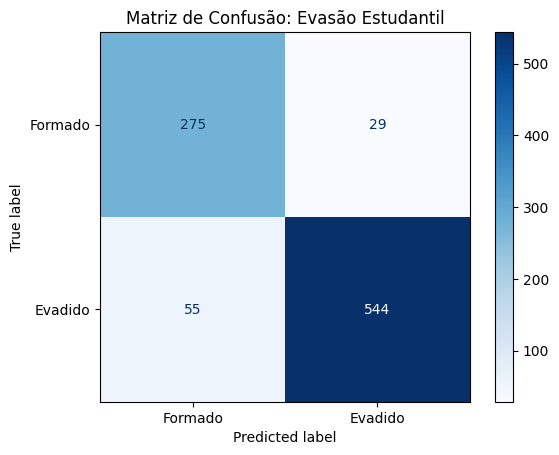

In [183]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cat.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Métricas Detalhadas ---")
print(classification_report(y_test, y_pred, target_names=['Formado (0)', 'Evadido (1)']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Formado', 'Evadido'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão: Evasão Estudantil')
plt.show()

In [184]:
# get the latest column of the active student
df_inference = df_full_sorted_ativos.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
df_latest_active = df_inference.groupby('RGA_Anon').tail(1).copy()

# same cleaning for the training
cat_features = X_train.columns[X_train.dtypes == 'object'].tolist() # Ou a lista que você usou
df_latest_active[cat_features] = df_latest_active[cat_features].fillna("Nao_Informado").astype(str)

# align columns
X_inference = df_latest_active[X_train.columns]

In [185]:
from catboost import Pool


inference_pool = Pool(
    data=X_inference, 
    cat_features=cat_features
)


probabilities = cat.predict_proba(inference_pool)[:, 1]

shap_values = cat.get_feature_importance(
    data=inference_pool, 
    type="ShapValues"
)


In [186]:
# ranking
df_ranking = pd.DataFrame({
    'RGA_Anon': df_latest_active['RGA_Anon'],
    'Probabilidade_Evasao': probabilities
}).sort_values(by='Probabilidade_Evasao', ascending=False)

df_ranking['Nivel_Alerta'] = pd.cut(
    df_ranking['Probabilidade_Evasao'], 
    bins=[0, 0.4, 0.7, 1.0], 
    labels=['Baixo', 'Moderado', 'Critico']
)

print(df_ranking.head(10))

                                              RGA_Anon  Probabilidade_Evasao  \
463  f7b1566071658dfa5835c6b0f4d76b3782c788d0384aa9...              0.999773   
228  bd52a37dd043a7e855d740a8c3fbf65a706d3834b93fdf...              0.999751   
459  0556fa5eef0b5bb73204902ce0a2787a8ab6a0f02c87dc...              0.999714   
827  1dc8f7eafa7a59825e380fa1016d7107373303149f4825...              0.999711   
683  598101ea7048e667fcbb1f3d7dea1576a0901b5113424d...              0.999651   
388  6b8c9ba1fd64fbb29734f479566f47882f4699321ffe23...              0.999641   
252  13042e6587b26a168e23d570a87b8584fc5c546827156f...              0.999635   
588  dbd5eaab24bfd494bef913ac1238a8da581fdd481f1a61...              0.999632   
0    d0770ffa6bc5cee42cb3151d4cda34fce038463a36848f...              0.999625   
734  8346f4265b94e141edc60f04aacbf4576a0cd55985633c...              0.999624   

    Nivel_Alerta  
463      Critico  
228      Critico  
459      Critico  
827      Critico  
683      Critico  
388  

In [187]:
x = df_ranking.iloc[0,0]
x

'f7b1566071658dfa5835c6b0f4d76b3782c788d0384aa9c0ddd5cfd398cca072'

In [188]:
df_ranking.tail(40)

,RGA_Anon,Probabilidade_Evasao,Nivel_Alerta
350,29d78a6b1b446a0a5d0fcb793d9596866fa115184d7e75...,0.428823,Moderado
757,1a98cf2424a9d8d77b75b6f5ca9d27d19dcdc788f9b9bf...,0.369256,Baixo
733,2e1f0d2edae9019eef72f68f62c43b72ddc7484902db5d...,0.346888,Baixo
676,0b8320d43d48be9e5d460753319f7b35b1d5c4df394120...,0.343096,Baixo
249,9dd100cde452af1098d819fb94d31f7d661247e5d5c44b...,0.342171,Baixo
545,6a71c3865ff8b82e383517f7d6a80cc822c23df21463b8...,0.338983,Baixo
56,a42bfd90e2f1ac78afeb6c021e90f41d55ad68b638ec6e...,0.316698,Baixo
510,c4ba2b0064f25237af365ef6d9b4785affd1d94931bd32...,0.315072,Baixo
392,26a4529c49a22a63440414ac9aec99a374b807c03a9eb3...,0.303489,Baixo
82,08b70cd82968c18578f64733b53d56ed3ea2bba66ad4a0...,0.277836,Baixo


In [189]:
rga = df_ranking.iloc[188, 0]

In [190]:
aluno = df_history_v15[df_history_v15['RGA_Anon']==rga]

In [192]:
aluno

,AnoSem,Idade_Academica,RGA_Anon,Reprovacao_Ponderada_Semestral,Reprovação_Media_Semestral,Período ingresso,Tempo_Permanencia_Em_Semestres,Lag_Academico_Em_Semestres,Lag_Academico_Delta,Coeficiente_Rendimento,Coeficiente_Rendimento_Delta,Modalidade_Ensino,Eficiencia_Academica,Eficiencia_Academica_Lag_03,Eficiencia_Academica_Lag_02,Eficiencia_Academica_Lag_01,Rolling_Reprovacao_Media_3_Semestres,Total_Falhas_Gatekeeper_Acumulado,Frequencia_Trend,Frequencia_Rolling_3S
5873,2023.1,0.0,41aa534ac9c9c07afb2e93cde06d60192e78b5af6d1eb4...,0.0,0.0,2023.1,1,1.0,0.0,6.443636,0.000000,Presencial,0.000000,NaN,NaN,NaN,0.0,0,NaN,97.916667
5879,2023.2,0.5,41aa534ac9c9c07afb2e93cde06d60192e78b5af6d1eb4...,0.0,0.0,2023.1,2,1.5,0.5,6.752500,0.308864,Presencial,0.250000,NaN,NaN,0.000000,0.0,0,-3.125000,96.354167
5885,2024.1,1.0,41aa534ac9c9c07afb2e93cde06d60192e78b5af6d1eb4...,0.0,0.0,2023.1,3,2.0,0.5,6.757568,0.005068,Presencial,0.333333,NaN,0.000000,0.250000,0.0,0,-4.613095,94.295635
5892,2024.2,1.5,41aa534ac9c9c07afb2e93cde06d60192e78b5af6d1eb4...,0.0,0.0,2023.1,4,2.5,0.5,6.593273,-0.164295,Presencial,0.375000,0.00,0.250000,0.333333,0.0,0,1.488095,92.212302
5901,2025.1,2.0,41aa534ac9c9c07afb2e93cde06d60192e78b5af6d1eb4...,0.0,0.0,2023.1,5,3.0,0.5,6.700435,0.107162,Presencial,0.400000,0.25,0.333333,0.375000,0.0,0,-4.613095,89.632937
